In [1]:
import re
import string
import nltk
import pandas as pd
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import html

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

#from nltk.tokenize import word_tokenize
#from nltk.stem import WordNetLemmatizer
#from nltk.corpus import stopwords

# Initialize lemmatizer and stopwords
#lemmatizer = WordNetLemmatizer()
#stopwords_list = set(stopwords.words('english'))

contractions = {
    r"\b i'm \b": " i am ",
    r"\b im \b": " i am ",
    r"\b don't \b": " do not ",
    r"\b dont \b": " do not ",
    r"\b doesn't \b": " does not ",
    r"\b doesnt \b": " does not ",
    r"\b haven't \b": " have not ",
    r"\b havent \b": " have not ",
    r"\b hasn't \b": " has not ",
    r"\b hasnt \b": " has not ",
    r"\b didn't \b": " did not ",
    r"\b didnt \b": " did not ",
    r"\b won't \b": " will not ",
    r"\b wont \b": " will not ",
    r"\b weren't \b": " were not ",
    r"\b werent \b": " were not ",
    r"\b can't \b": " can not ",
    r"\b cant \b": " can not ",
    r"\b couldn't \b": " could not ",
    r"\b couldnt \b": " could not ",
    r"\b wouldn't \b": " would not ",
    r"\b wouldnt \b": " would not ",
    r"\b isn't \b": " is not ",
    r"\b isnt \b": " is not ",
    r"\b aren't \b": " are not ",
    r"\b arent \b": " are not ",
    r"\b ur \b": " you are ",
    r"\b ure \b": " you are ",
    r"\b aree \b": " are "
}

def cleaning(text):
    text = text.lower().strip()  # Convert to lowercase and remove white spaces
    
    # Expand contractions
    for phrase, replacement in contractions.items():
        text = re.sub(phrase, replacement, text, flags=re.IGNORECASE)

    text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U000024C2-\U0001F251]', '', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&quot;', '"', text)
    
    # Remove non-ASCII characters
    text = text.encode('ascii', 'ignore').decode()

    # Replace mentions, URLs, numbers, and punctuation
    text = re.sub(r'@\S+', 'mention', text)
    text = re.sub(r'http\S+', 'url', text)
    #text = re.sub(r'\d+', '', text) #meiwse
    text = re.sub(r'[' + string.punctuation + ']', ' ', text)

    # Tokenize and lemmatize
    #tokens = word_tokenize(text)
    #tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stopwords_list and len(word) > 1]  # Remove stopwords & single-letter words: den etrekse, meiwse validate
    #text = " ".join(tokens).strip()  # Join words back into a cleaned text
    text = text.strip()
    return text # Join words back into a string

2025-06-08 14:12:26.532755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749391946.706110      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749391946.755642      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Epoch 1/3 - Train Acc: 0.8140, Val Acc: 0.8364


Epoch 2/3: 100%|██████████| 4638/4638 [16:08<00:00,  4.79it/s, loss=0.0193]


Epoch 2/3 - Train Acc: 0.8685, Val Acc: 0.8497


Epoch 3/3: 100%|██████████| 4638/4638 [16:10<00:00,  4.78it/s, loss=0.222]


Epoch 3/3 - Train Acc: 0.9105, Val Acc: 0.8469
Best Validation Accuracy: 0.8497


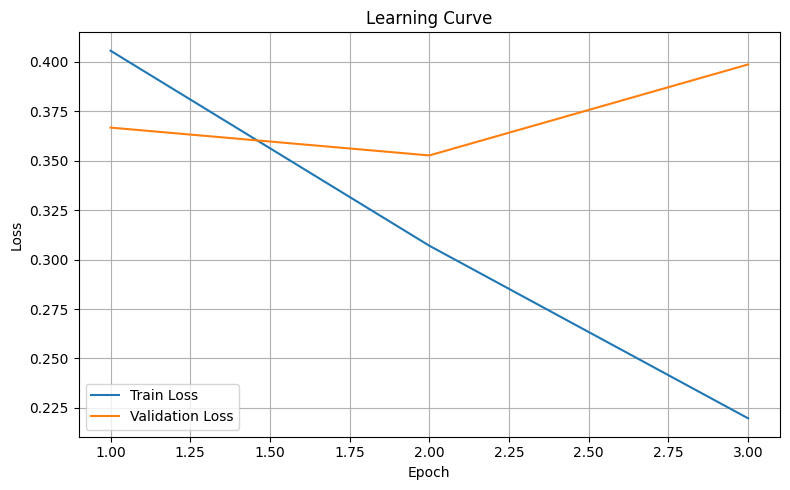

Validation Accuracy: 0.8496556279
Precision: 0.8498277408
Recall: 0.8494268598
F1 Score: 0.8496272530


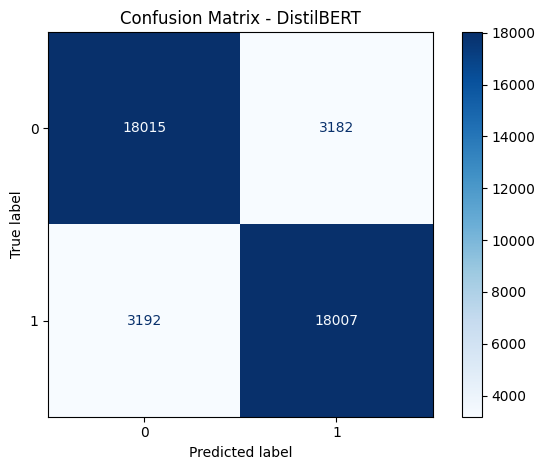

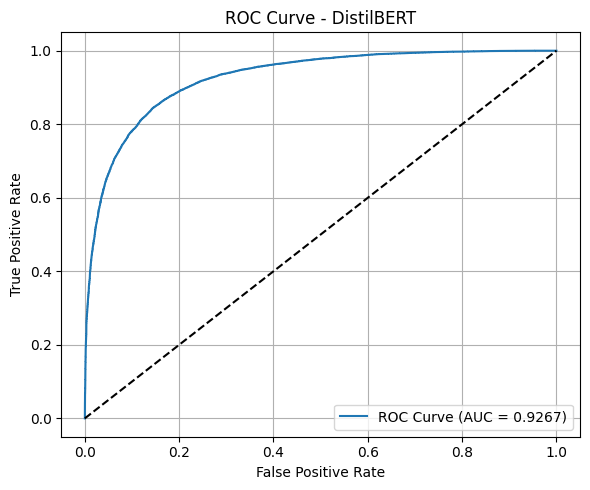

Test predictions saved!


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertModel, get_cosine_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

train_path = "/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/train_dataset.csv"
val_path = "/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/val_dataset.csv"
test_path = "/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/test_dataset.csv"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)


#train_df["Text"] = train_df["Text"].apply(cleaning)
#valid_df["Text"] = valid_df["Text"].apply(cleaning)
#test_df["Text"] = test_df["Text"].apply(cleaning)

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")


class DistilBERTDataset(Dataset):
    def __init__(self, texts, labels=None, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels) if labels is not None else None
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        item = {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


g = torch.Generator()
g.manual_seed(42)

train_dataset = DistilBERTDataset(train_df["Text"].tolist(), train_df["Label"].tolist())
val_dataset = DistilBERTDataset(valid_df["Text"].tolist(), valid_df["Label"].tolist())
test_dataset = DistilBERTDataset(test_df["Text"].tolist(), None)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


class DistilBERTClassifier(nn.Module):
    def __init__(self, dropout=0.2):
        super(DistilBERTClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = outputs.last_hidden_state  
        pooled_output = hidden_state[:, 0]
        x = self.dropout(pooled_output)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBERTClassifier()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
total_steps = len(train_loader) * 4
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=(0.05 * total_steps), num_training_steps=total_steps)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=3):
    best_acc = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, total_correct = 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            _, preds = torch.max(outputs, dim=1)
            total_loss += loss.item()
            total_correct += torch.sum(preds == labels)

            loop.set_postfix(loss=loss.item())

        epoch_loss = total_loss / len(train_loader)
        train_losses.append(epoch_loss)
        train_acc = total_correct.double() / len(train_loader.dataset)

        val_loss = 0
        val_preds, val_labels = [], []
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_acc = accuracy_score(val_labels, val_preds)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_distilbert_model.pt")

    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # Learning Curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
    plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=3)


model.load_state_dict(torch.load("best_distilbert_model.pt"))
model.eval()


val_preds = []
val_probs = []
val_true = valid_df["Label"].tolist()

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(val_true, val_preds)
precision = precision_score(val_true, val_preds)
recall = recall_score(val_true, val_preds)
f1 = f1_score(val_true, val_preds)

print(f"Validation Accuracy: {accuracy:.10f}")
print(f"Precision: {precision:.10f}")
print(f"Recall: {recall:.10f}")
print(f"F1 Score: {f1:.10f}")


cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - DistilBERT")
plt.grid(False)
plt.tight_layout()
plt.show()


fpr, tpr, _ = roc_curve(val_true, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


model.load_state_dict(torch.load("best_distilbert_model.pt"))
model.eval()


test_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, dim=1)
        test_preds.extend(preds.cpu().numpy())

test_df["Label"] = test_preds
test_df[["ID", "Label"]].to_csv("submission.csv", index=False)
print("Test predictions saved!")

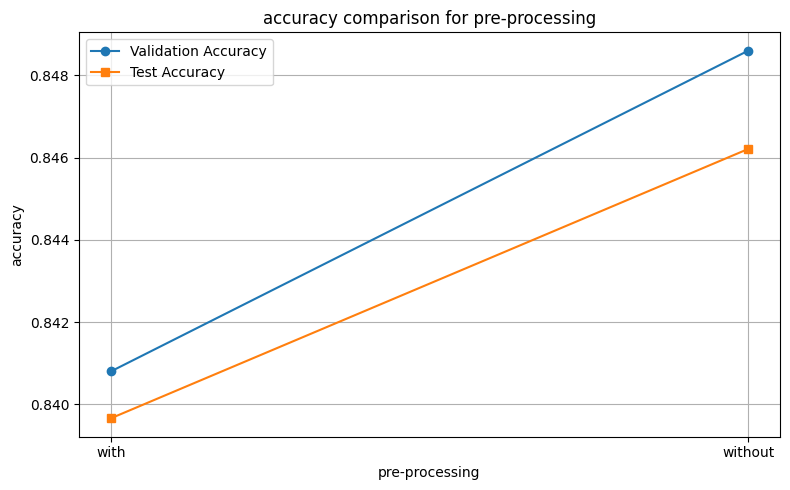

In [3]:
import matplotlib.pyplot as plt

# Data
process = ["with", "without"]
val_accuracy = [0.8408, 0.8486]
test_accuracy = [0.83966, 0.84621]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(process, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(process, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for pre-processing')
plt.xlabel('pre-processing')
plt.ylabel('accuracy')
plt.xticks(process)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

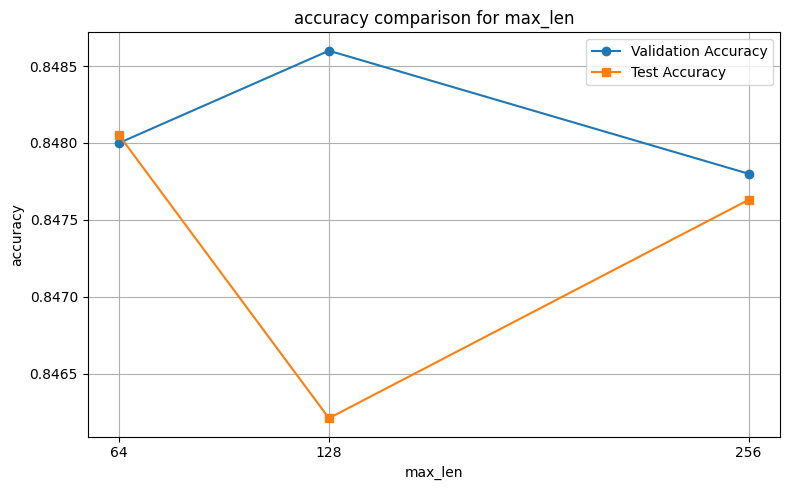

In [4]:
import matplotlib.pyplot as plt

# Data
maxx = [64, 128, 256]
val_accuracy = [0.8480, 0.8486, 0.8478]
test_accuracy = [0.84805, 0.84621, 0.84763]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(maxx, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(maxx, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for max_len')
plt.xlabel('max_len')
plt.ylabel('accuracy')
plt.xticks(maxx)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

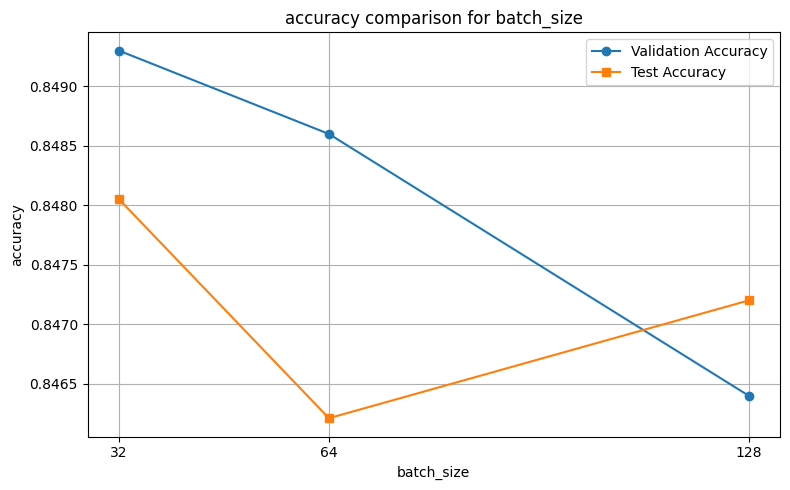

In [5]:
import matplotlib.pyplot as plt

# Data
batch = [32, 64, 128]
val_accuracy = [0.8493, 0.8486 ,0.8464]
test_accuracy = [0.84805, 0.84621, 0.84720]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(batch, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(batch, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for batch_size')
plt.xlabel('batch_size')
plt.ylabel('accuracy')
plt.xticks(batch)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

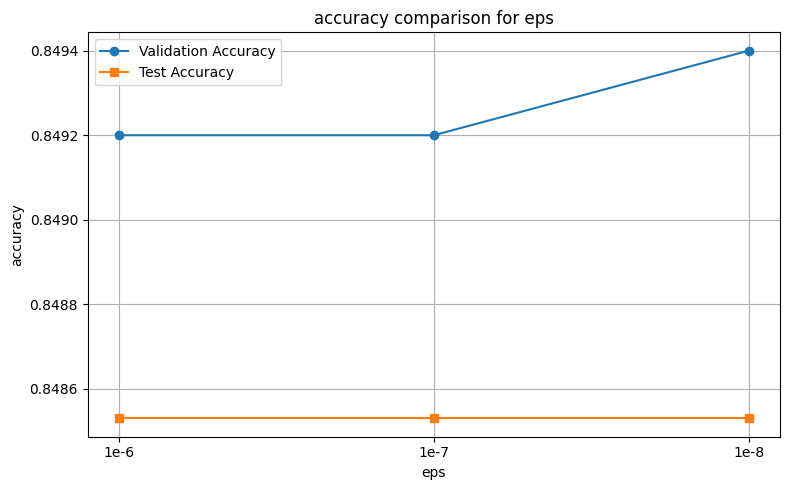

In [6]:
import matplotlib.pyplot as plt

# Data
eps = ["1e-6", "1e-7", "1e-8"]
val_accuracy = [0.8492, 0.8492, 0.8494]
test_accuracy = [0.84853, 0.84853, 0.84853]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(eps, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(eps, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for eps')
plt.xlabel('eps')
plt.ylabel('accuracy')
plt.xticks(eps)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

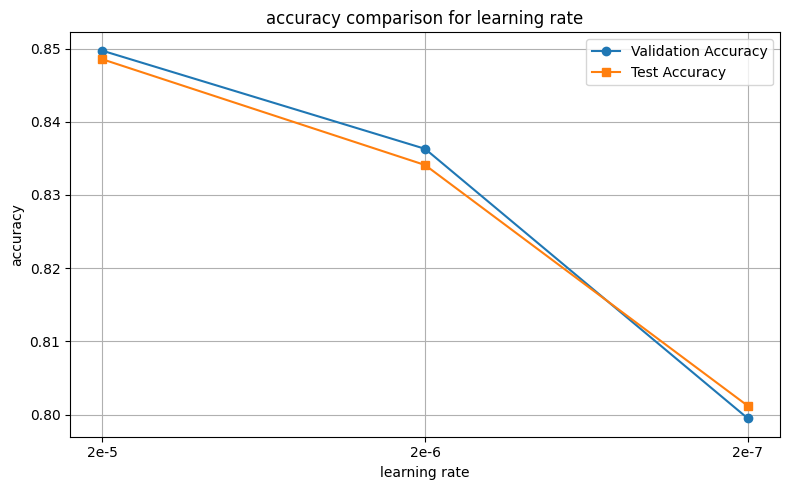

In [7]:
import matplotlib.pyplot as plt

# Data
lrs = ["2e-5", "2e-6", "2e-7"]
val_accuracy = [0.8497, 0.8363, 0.7995]
test_accuracy = [0.84853, 0.83409, 0.80121]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lrs, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(lrs, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for learning rate')
plt.xlabel('learning rate')
plt.ylabel('accuracy')
plt.xticks(lrs)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

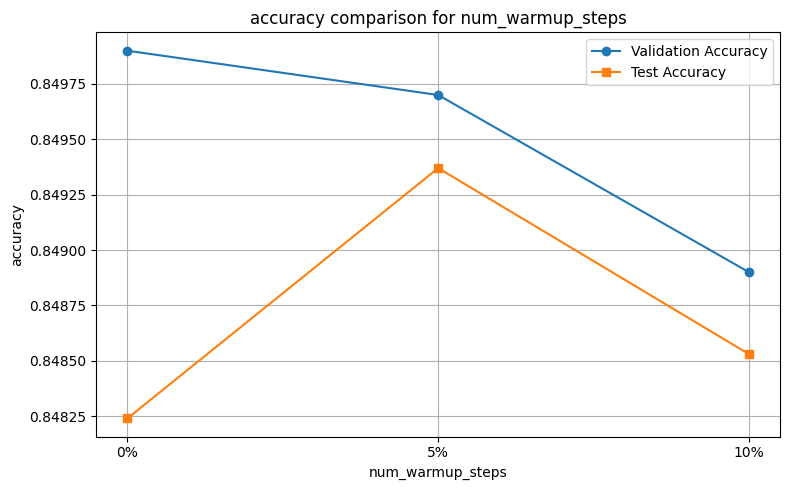

In [8]:
import matplotlib.pyplot as plt

# Data
warmups = ["0%", "5%", "10%"]
val_accuracy = [0.8499, 0.8497, 0.8489]
test_accuracy = [0.84824, 0.84937, 0.84853]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(warmups, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(warmups, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for num_warmup_steps')
plt.xlabel('num_warmup_steps')
plt.ylabel('accuracy')
plt.xticks(warmups)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

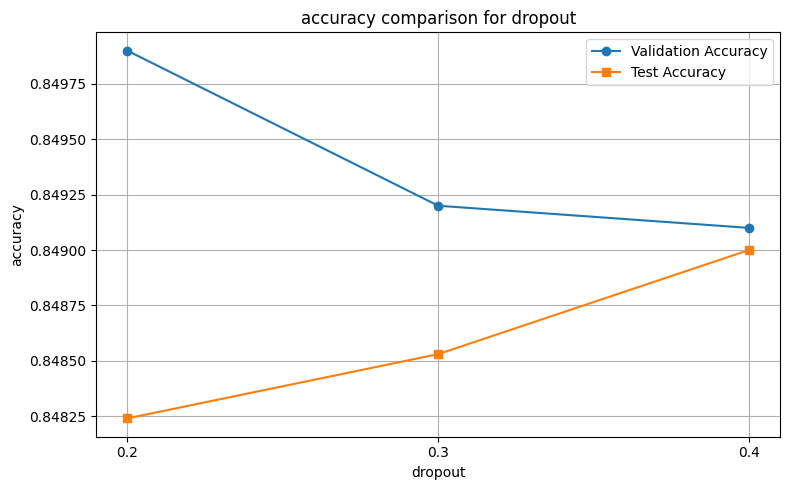

In [9]:
import matplotlib.pyplot as plt

# Data
dropouts = [0.2, 0.3, 0.4]
val_accuracy = [0.8499, 0.8492, 0.8491]
test_accuracy = [0.84824, 0.84853, 0.84900]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(dropouts, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(dropouts, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for dropout')
plt.xlabel('dropout')
plt.ylabel('accuracy')
plt.xticks(dropouts)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()